In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
import os
from sklearn.preprocessing import StandardScaler

In [2]:

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')


In [3]:
# Import data:
#df = pd.read_csv("top50_features.csv") 
#X = df.drop(columns=['Date']) 
#data = X.dropna()
# Import data:

# Data import:
df_factor = pd.read_csv("value_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_curve = pd.read_csv("curve_features_reduced.csv", parse_dates=['Date'])
df_curve = df_curve.set_index('Date')

df_additional = pd.read_csv("additional_features.csv", parse_dates=['Date'])
df_additional = df_additional.set_index('Date')

df_relative_factors = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_relative_factors = df_relative_factors.set_index('Date')

In [4]:
def create_lagged_features(df, lags=[1]):

    df_lagged = pd.DataFrame(index=df.index)
    for col in df.columns:
        for lag in lags:
            df_lagged[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df_lagged
        
        # Create lagged versions of all features
        
    # Apply required lag to features
df_curve_lagged = create_lagged_features(df_curve, lags=[1])
df_additional_lagged = create_lagged_features(df_additional, lags=[1])
df_relative_factors_lagged = create_lagged_features(df_relative_factors, lags=[1])

    # Combine features first
df_features = pd.concat([df_curve_lagged, df_additional_lagged, df_relative_factors_lagged], axis=1, join='inner')

    # Calculate missing value percentages
missing_percent = df_features.isnull().mean() * 100

    # Identify features to keep (<= 10% missing)
features_to_keep = missing_percent[missing_percent <= 30].index

    # Filter features
df_features = df_features[features_to_keep]

    # Now impute remaining missing values with mean
    #df_features = df_features.fillna(df_features.mean())
df_features = df_features.ffill().bfill()

    # Combine with target
data = pd.concat([df_features, df_factor], axis=1, join='inner').dropna()

print("Remaining features after filtering:")
print(data.columns)
print(f"\nOriginal feature count: {len(df_curve.columns) + len(df_additional.columns)}")
print(f"Final feature count: {len(df_features.columns)}")

    # Optional: Show dropped features
dropped_features = missing_percent[missing_percent > 30].index
if len(dropped_features) > 0:
    print("\nDropped features (>10% missing):")
    for feat in dropped_features:
        print(f"{feat}: {missing_percent[feat]:.2f}% missing")
else:
    print("\nNo features had >10% missing values")


Remaining features after filtering:
Index(['SA_NB_Level_lag1', 'SA_NB_Slope_lag1', 'SA_NB_Curvature_lag1',
       'SA_NB_Level_QS_lag1', 'SA_NB_Slope_QS_lag1', 'SA_NB_Curvature_QS_lag1',
       'SA_NB_Level_TS_lag1', 'SA_NB_Slope_TS_lag1', 'US_NB_Level_lag1',
       'US_NB_Slope_lag1', 'US_NB_Curvature_lag1', 'US_NB_Level_QS_lag1',
       'US_NB_Slope_QS_lag1', 'US_NB_Curvature_QS_lag1', 'US_NB_Level_TS_lag1',
       'US_NB_Slope_TS_lag1', 'Momentum_excess_momentum_lag1',
       'Momentum_excess_volatility_lag1', 'Momentum_excess_kurtosis_lag1',
       'Momentum_excess_skewness_lag1', 'Value_excess_momentum_lag1',
       'Value_excess_volatility_lag1', 'Value_excess_kurtosis_lag1',
       'Value_excess_skewness_lag1', 'Quality_excess_momentum_lag1',
       'Quality_excess_volatility_lag1', 'Quality_excess_kurtosis_lag1',
       'Quality_excess_skewness_lag1', 'Momentum_relative_volatility_lag1',
       'Momentum_relative_kurtosis_lag1', 'Momentum_relative_skewness_lag1',
       'Value_

In [5]:
# Check for missing/infinite values
print("Missing values per column before handling:")
print(data.isna().sum())

# Drop columns with too many missing values (>20%)
data = data.dropna(axis=1, thresh=0.8*len(data)) 

X = data.iloc[:, :-1]
#y = df_factor['trend_bin'].values

X = pd.DataFrame(
    np.nan_to_num(X.values, nan=0.0, posinf=1e10, neginf=-1e10), 
    columns=X.columns, 
    index=X.index
)

# Normalize the features
scaler = StandardScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)



Missing values per column before handling:
SA_NB_Level_lag1                    0
SA_NB_Slope_lag1                    0
SA_NB_Curvature_lag1                0
SA_NB_Level_QS_lag1                 0
SA_NB_Slope_QS_lag1                 0
                                   ..
Value_vs_Quality_Cumulative_lag1    0
Momentum_vs_Value_trend_lag1        0
Value_vs_Quality_trend_lag1         0
Momentum_vs_Quality_trend_lag1      0
trend_bin                           0
Length: 66, dtype: int64


In [6]:
# Calculate correlation matrix
corr = normalized_data.corr()

# Check for NaN or infinite values in correlation matrix
if np.isnan(corr.values).any() or np.isinf(corr.values).any():
    print("Warning: Correlation matrix still contains NaN or infinite values")
    
    # Replace any remaining NaN/inf values with 0 (no correlation)
    corr = corr.fillna(0)
    corr = corr.replace([np.inf, -np.inf], 0)

In [7]:
# Distance matrix for hierarchical clustering
distance = 1 - np.abs(corr)

# Verify distance matrix contains no NaN/inf values
assert not np.isnan(distance.values).any(), "Distance matrix contains NaN values"
assert not np.isinf(distance.values).any(), "Distance matrix contains infinite values"

# Distance matrix for hierarchical clustering
#distance = 1 - np.abs(corr)

# Hierarchical clustering
linkage = hierarchy.linkage(distance, method='complete')


C:\Users\p528552\AppData\Local\Temp\ipykernel_33636\3474408499.py:12: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(distance, method='complete')


C:\Users\p528552\AppData\Local\Temp\ipykernel_33636\3163716736.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 2000x2000 with 0 Axes>

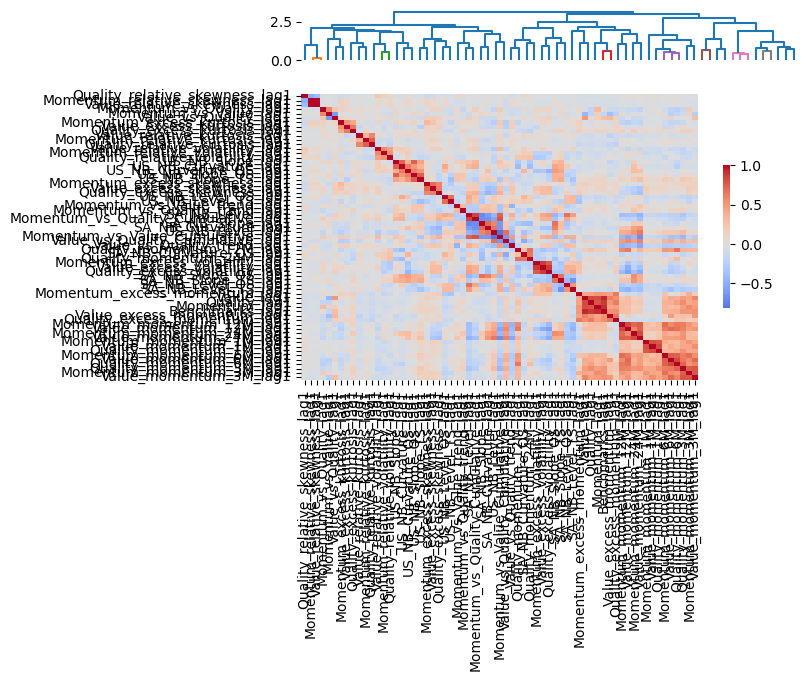

In [8]:

# Create the heatmap with dendrogram
plt.figure(figsize=(20, 20))  # Adjust size as needed

# Create a gridspec to add dendrogram on top and side
grid_kws = {"height_ratios": (.15, .85), "hspace": 0.2}
f, (dendro_ax, heatmap_ax) = plt.subplots(2, 1, gridspec_kw=grid_kws)

# Dendrogram on top
dendro = hierarchy.dendrogram(
    linkage,
    ax=dendro_ax,
    orientation='top',
    labels=distance.columns,
    color_threshold=0.7  # Adjust this to change cluster separation
)
dendro_ax.spines['top'].set_visible(False)
dendro_ax.spines['right'].set_visible(False)
dendro_ax.spines['bottom'].set_visible(False)
dendro_ax.spines['left'].set_visible(False)
dendro_ax.tick_params(axis='x', which='both', length=0)
dendro_ax.set_xticks([])  # Remove x-axis labels for dendrogram

# Reorder the data based on the clustering
reordered_idx = dendro['leaves']
reordered_corr = corr.iloc[reordered_idx, reordered_idx]

# Heatmap
heatmap = sns.heatmap(
    reordered_corr,
    ax=heatmap_ax,
    cmap='coolwarm',
    center=0,
    xticklabels=reordered_corr.columns,
    yticklabels=reordered_corr.columns,
    cbar_kws={"shrink": 0.5}
)

# Rotate x-axis labels for better readability
heatmap_ax.set_xticklabels(
    heatmap_ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='center'
)

plt.tight_layout()
plt.show()

In [9]:
# Filter for high correlations
def get_high_correlations(corr_matrix, threshold):
    # Get absolute correlations (ignore sign)
    c = corr_matrix.abs()

    # Mask the diagonal and lower triangle (to avoid duplicates)
    upper = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))

    # Find pairs above threshold
    high_corr = (
        upper.stack()
        .reset_index()
        .rename(columns={0: "correlation", "level_0": "feature1", "level_1": "feature2"})
    )
    return high_corr[high_corr["correlation"] > threshold].sort_values(by="correlation", ascending=False)

# Set threshold and get correlations pairs above threshold
high_corr_pairs = get_high_correlations(corr, threshold=0.75)

print("Highly correlated feature pairs:")
print(high_corr_pairs.head(20))   


Highly correlated feature pairs:
                               feature1                             feature2  \
1487    Momentum_relative_skewness_lag1         Value_relative_skewness_lag1   
2015                         Value_lag1                      Benchmarks_lag1   
2004                      Momentum_lag1                      Benchmarks_lag1   
1137       Value_excess_volatility_lag1       Quality_excess_volatility_lag1   
955     Momentum_excess_volatility_lag1         Value_excess_volatility_lag1   
2025                       Quality_lag1                      Benchmarks_lag1   
59                     SA_NB_Level_lag1  Momentum_vs_Quality_Cumulative_lag1   
1784         Momentum_momentum_12M_lag1              Value_momentum_12M_lag1   
1831             Value_momentum_1M_lag1             Quality_momentum_1M_lag1   
2014                         Value_lag1                         Quality_lag1   
1874             Value_momentum_6M_lag1             Quality_momentum_6M_lag1   
1808   

In [10]:
# Step 1: Pick one feature from each highly correlated pair

variances = normalized_data.var()

# Step 2: Decide which feature to drop for each correlated pair
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["feature1"], row["feature2"]
    
    # Compare variances, drop the one with lower variance
    if variances[f1] < variances[f2]:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

print("\nFeatures to drop due to high correlation:")
print(to_drop)

# Step 2: Drop them from your dataset
reduced_data = data.drop(columns=list(to_drop))

# Step 3: Add back target column
final_data = pd.concat([reduced_data, data["trend_bin"]], axis=1)

# Step 4: Save to CSV
final_data.to_csv("reduced_dataset.csv", index=True)

print(f"\nFinal dataset saved with {final_data.shape[1]} columns (features + target).")



Features to drop due to high correlation:
{'Quality_momentum_6M_lag1', 'Value_relative_skewness_lag1', 'Quality_relative_kurtosis_lag1', 'Quality_momentum_3M_lag1', 'Value_lag1', 'Quality_excess_volatility_lag1', 'Value_momentum_6M_lag1', 'Momentum_excess_volatility_lag1', 'Benchmarks_lag1', 'Momentum_vs_Value_Cumulative_lag1', 'Value_momentum_24M_lag1', 'Momentum_momentum_3M_lag1', 'Momentum_momentum_12M_lag1', 'Value_momentum_1M_lag1', 'Momentum_vs_Quality_Cumulative_lag1', 'Quality_momentum_1M_lag1', 'Quality_lag1'}

Final dataset saved with 50 columns (features + target).
